In [12]:
import numpy as np
import random
from math import exp,log
import matplotlib.pyplot as plt

In [13]:
# Data prepration
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

In [14]:
# Model
class logistic_regression_model():
    def __init__(self):
        self.w = [random.random(), random.random()]
        self.b = random.random()
        
    def sigmoid(self, z):
        return 1/(1 + exp(-z))
    
    def predict(self, x):
        z = np.inner(self.w, x) + self.b
        a = self.sigmoid(z)
        return a

In [15]:
AND_model1 = logistic_regression_model()
AND_model2 = logistic_regression_model()
AND_model3 = logistic_regression_model()

In [16]:
# Training
def train(X, Y, model, lr):
    dw0 = 0.0
    dw1 = 0.0
    db = 0.0
    m = len(X)
    cost = 0.0
    
    for x, y in zip(X, Y):
        a = model.predict(x)
        if y == 1:
            cost -= log(a)
        else:
            cost -= log(1-a)
            
        dw0 += (a-y)*x[0]
        dw1 += (a-y)*x[1]
        db += (a-y)
            
    cost /= m
    model.w[0] -= lr * dw0/m
    model.w[1] -= lr * dw1/m
    model.b -= lr * db/m
        
    return cost

In [17]:
AND_loss1 = []
AND_loss2 = []
AND_loss3 = []

for epoch in range(10000):
        # learning rate 0.01
        AND_loss1.append(train(X, Y, AND_model1, 0.01))
        # learning rate 0.1
        AND_loss2.append(train(X, Y, AND_model2, 0.1))
        # learning rate 0.5
        AND_loss3.append(train(X, Y, AND_model3, 0.5))

epoch = [x for x in range(10000)]

AND_loss1 = np.array(AND_loss1)
AND_loss2 = np.array(AND_loss2)
AND_loss3 = np.array(AND_loss3)

In [18]:
# learning rate = 0.01
print(AND_model1.predict((0,0)))
print(AND_model1.predict((0,1)))
print(AND_model1.predict((1,0)))
print(AND_model1.predict((1,1)))

0.00792859641060618
0.14741435376751927
0.14771807939925719
0.7894612403097381


In [19]:
# learning rate = 0.1
print(AND_model2.predict((0,0)))
print(AND_model2.predict((0,1)))
print(AND_model2.predict((1,0)))
print(AND_model2.predict((1,1)))

1.2342581341650152e-05
0.02018263204956065
0.020182633437800405
0.9717321637284012


In [20]:
# learning rate = 0.5
print(AND_model3.predict((0,0)))
print(AND_model3.predict((0,1)))
print(AND_model3.predict((1,0)))
print(AND_model3.predict((1,1)))

9.369718386893245e-08
0.00404139215159124
0.00404139215149651
0.9943417407639188


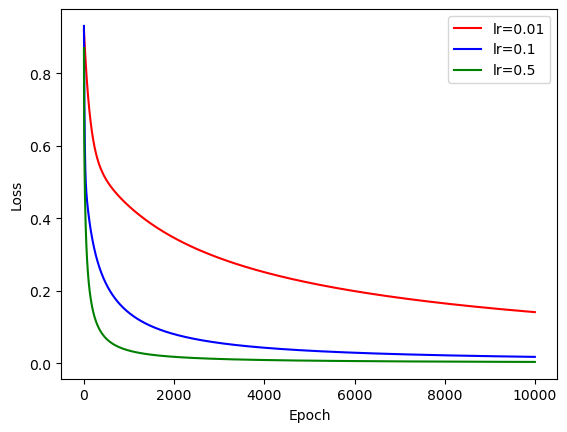

In [27]:
# loss plot
plt.plot(epoch, AND_loss1, 'r-', label = 'lr=0.01')
plt.plot(epoch, AND_loss2, 'b-', label = 'lr=0.1')
plt.plot(epoch, AND_loss3, 'g-', label = 'lr=0.5')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()